# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

  Obtaining dependency information for gensim from https://files.pythonhosted.org/packages/fd/f2/9ec6863143888bf390cdc5261f6d9e71d79bc95d98fb815679dba478d5f6/gensim-4.4.0-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for transformers from https://files.pythonhosted.org/packages/29/fb/162a66789c65e5afa3b051309240c26bf37fbc8fea285b4546ae747995a2/transformers-5.5.4-py3-none-any.whl.metadata
  Obtaining dependency information for sentence-transformers from https://files.pythonhosted.org/packages/c5/d9/3a9b6f2ccdedc9dc00fe37b2fc58f58f8efbff44565cf4bf39d8568bb13a/sentence_transformers-5.4.1-py3-none-any.whl.metadata
  Obtaining dependency information for datasets from https://files.pythonhosted.org/packages/b0/e5/247d094108e42ac26363ab8dc57f168840cf7c05774b40ffeb0d78868fcc/datasets-4.8.4-py3-none-any.whl.metadata
  Obtaining dependency information for tokenizers<=0.23.0,>=0.22.0 from https://files.pythonhosted.org/packages/65/71/0670843133a43d43070abeb1949abfdef12a86d


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [10]:
import pandas as pd

# Load the dataset
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}

df = pd.read_json("hf://datasets/SetFit/20_newsgroups/" + splits["train"], lines=True)  # YOUR CODE HERE

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["rec.sport.hockey", "sci.space", "talk.politics.mideast"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['rec.sport.hockey', 'sci.space', 'talk.politics.mideast']
Filtered dataset size: 1757


In [12]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove non-alphabetic characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Collapse multiple whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok) 
        for tok in tokens
        if tok not in stop_words and len(tok) > 2
    ]
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['article', 'tombaker', 'world', 'std', 'com', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'right', 'value']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [13]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1757 documents
Total tokens: 221050

Sample document tokens: ['article', 'tombaker', 'world', 'std', 'com', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system']


In [14]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 6240


In [15]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 6240


### A.2 Exploring Word Embeddings

In [16]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.2990186   0.12557226 -0.00342112 -0.2063925   0.01138803 -0.86761105
 -0.25462252  0.85238016 -0.24160925  0.15403244]


In [17]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")
    
    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  engineering: 0.9941
  application: 0.9934
  access: 0.9923
  analysis: 0.9904
  user: 0.9901
  facility: 0.9895
  operation: 0.9891
  unix: 0.9888
  remote: 0.9885
  element: 0.9883

Words most similar to 'computer' (Skip-gram):
  macintosh: 0.8794
  interactive: 0.8733
  matloff: 0.8700
  automated: 0.8681
  ad: 0.8593
  provides: 0.8567
  ephemeris: 0.8561
  processing: 0.8560
  database: 0.8559
  algorithm: 0.8555


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [19]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["hockey", "space", "armenian", "nasa", "player"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]
        
        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })
        
        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'hockey':
  CBOW:     ['league', 'nhl', 'team', 'player', 'sport']
  Skip-gram: ['sport', 'nhl', 'basketball', 'football', 'roster']

'space':
  CBOW:     ['sci', 'station', 'program', 'commercial', 'nasa']
  Skip-gram: ['technology', 'sci', 'aerospace', 'exploration', 'astro']

'armenian':
  CBOW:     ['kurd', 'azeri', 'turk', 'massacre', 'muslim']
  Skip-gram: ['perpetrated', 'fascist', 'kurd', 'struggle', 'thirsty']

'nasa':
  CBOW:     ['gov', 'ames', 'ftp', 'server', 'kelvin']
  Skip-gram: ['larc', 'egalon', 'ames', 'jsc', 'dryden']

'player':
  CBOW:     ['team', 'nhl', 'best', 'fan', 'canadian']
  Skip-gram: ['minus', 'superstar', 'statistic', 'nhl', 'playing']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: hockey and space. Both models retrieve the domain's lexical field (nhl, sport for hockey; sci, nasa/aerospace for space).
2. Different results for: armenian, nasa, player.
- armenian: CBOW gives neighboring ethnic groups (kurd,azeri, turk), Skip-gram gives the newsgroup's political register (perpetrated, fascist, struggle).
- nasa: CBOW returns email signature fragments (gov, ftp, server), Skip-gram identifies actual NASA research centers (larc, ames, jsc, dryden).
- player: CBOW stays generic (team, fan), Skip-gram surfaces specialized hockey vocabulary (superstar, statistic, minus).

3. Better model for my domain: Skip-gram.
   - Example 1: (nasa): Skip-gram recovers the real NASA centers (Langley, Ames, Johnson, Dryden), CBOW stays at the surface.
   - Example 2: (armenian): Skip-gram captures the newsgroup's rhetoric, which matches the actual content of talk.politics.mideast.

4. Explanation of differences: CBOW averages the context, so it favors frequent words and smooths out rare ones.
Skip-gram predicts each context word separately, giving a stronger signal on rare and domain-specific words.
On a specialized mid-size corpus like 20 Newsgroups, the useful information is carried by rare words, so Skip-gram wins. On a massive generic corpus, CBOW would catch up.

### A.3 Word Analogies

In [20]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [21]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "nhl", "hockey", "nba")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "nasa", "space", "israel")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('hiring', 0.7504304647445679), ('loved', 0.7481728196144104), ('drew', 0.7401406168937683), ('cbc', 0.7365856766700745), ('kidding', 0.7349352836608887)]
Analogy 2: [('lebanon', 0.5739330649375916), ('palestinian', 0.5534332394599915), ('arab', 0.5527758002281189), ('peace', 0.5430454015731812), ('jordan', 0.540599524974823)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?** 
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

Analogy 1 failed. Expected "basketball" but got random words. The word "nba" is too rare in a hockey-focused corpus, so its vector is weak.
Analogy 2 worked. Got lebanon, palestinian, arab, peace, jordan, all Middle East countries and terms. The model learned "israel" as a political entity in the region, so shifting from space to politics gave a clean result.


---

## Part B: Pre-trained GloVe Embeddings 

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [22]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [23]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  macintosh: 0.8794
  interactive: 0.8733
  matloff: 0.8700
  automated: 0.8681
  ad: 0.8593
  provides: 0.8567
  ephemeris: 0.8561
  processing: 0.8560
  database: 0.8559
  algorithm: 0.8555

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [24]:
# TODO: Compare 3 domain-specific words

comparison_words = ["nasa", "hockey", "palestine"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")
    
    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")
    
    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'nasa'
Your Word2Vec:
  larc: 0.844
  egalon: 0.814
  ames: 0.790
  jsc: 0.778
  dryden: 0.774
GloVe:
  shuttle: 0.778
  astronauts: 0.764
  spacecraft: 0.709
  space: 0.704
  endeavour: 0.692

Word: 'hockey'
Your Word2Vec:
  sport: 0.813
  nhl: 0.746
  basketball: 0.723
  football: 0.715
  roster: 0.705
GloVe:
  basketball: 0.804
  football: 0.783
  nhl: 0.760
  soccer: 0.744
  baseball: 0.731

Word: 'palestine'
Your Word2Vec:
  jerusalem: 0.898
  jordanian: 0.872
  mandate: 0.871
  landlord: 0.859
  jordan: 0.854
GloVe:
  israel: 0.697
  plo: 0.693
  arab: 0.685
  jerusalem: 0.681
  lebanon: 0.673


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. My model is better for: nasa and palestine
      - nasa: my model returns actual NASA research centers (larc, ames, jsc, dryden), very specific. GloVe gives generic space vocabulary (shuttle, astronauts, spacecraft).
      - palestine: my model captures the concrete local context of the newsgroup (jerusalem, jordanian, mandate, jordan). GloVe gives a more abstract geopolitical view (israel, plo, arab).

   - Reason: my model was trained directly on the newsgroup texts, so it learned the fine-grained vocabulary of those specific discussions.


2. GloVe is better for: hockey.

GloVe returns a clean list of other sports (basketball, football, soccer, baseball, nhl). My model gives a similar list but less clean (includes roster).

   - Reason: GloVe was trained on Wikipedia and Gigaword, with massive coverage of generic topics like sports.

3. When to use each:
   - Custom model:  when the task needs domain-specific vocabulary (technical terms, jargon, entities) that a generic model does not know well.
   - Pre-trained model:  when the task is generic, the corpus is small, or you need broad coverage of common vocabulary without training cost.

### B.2 GloVe Analogies

In [25]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [28]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: paris - france + spain = ? → expect madrid
result1 = glove_model.most_similar(positive=['paris', 'spain'], negative=['france'], topn=3)
print("paris - france + spain = ?")
for word, score in result1:
    print(f"  {word}: {score:.4f}")

# Analogy 2: earth - planet + sun = ? → expect star
result2 = glove_model.most_similar(positive=['earth', 'sun'], negative=['planet'], topn=3)
print("\nearth - planet + sun = ?")
for word, score in result2:
    print(f"  {word}: {score:.4f}")

# Analogy 3: football - soccer + hockey = ? → expect ice or nhl
result3 = glove_model.most_similar(positive=['football', 'hockey'], negative=['soccer'], topn=3)
print("\nfootball - soccer + hockey = ?")
for word, score in result3:
    print(f"  {word}: {score:.4f}")

paris - france + spain = ?
  madrid: 0.8061
  aires: 0.7141
  buenos: 0.6975

earth - planet + sun = ?
  light: 0.5933
  wind: 0.5729
  sunlight: 0.5715

football - soccer + hockey = ?
  basketball: 0.7445
  nhl: 0.7008
  baseball: 0.6836


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [29]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10747.13it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded!


In [30]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [31]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity, 
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [32]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [34]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)  # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


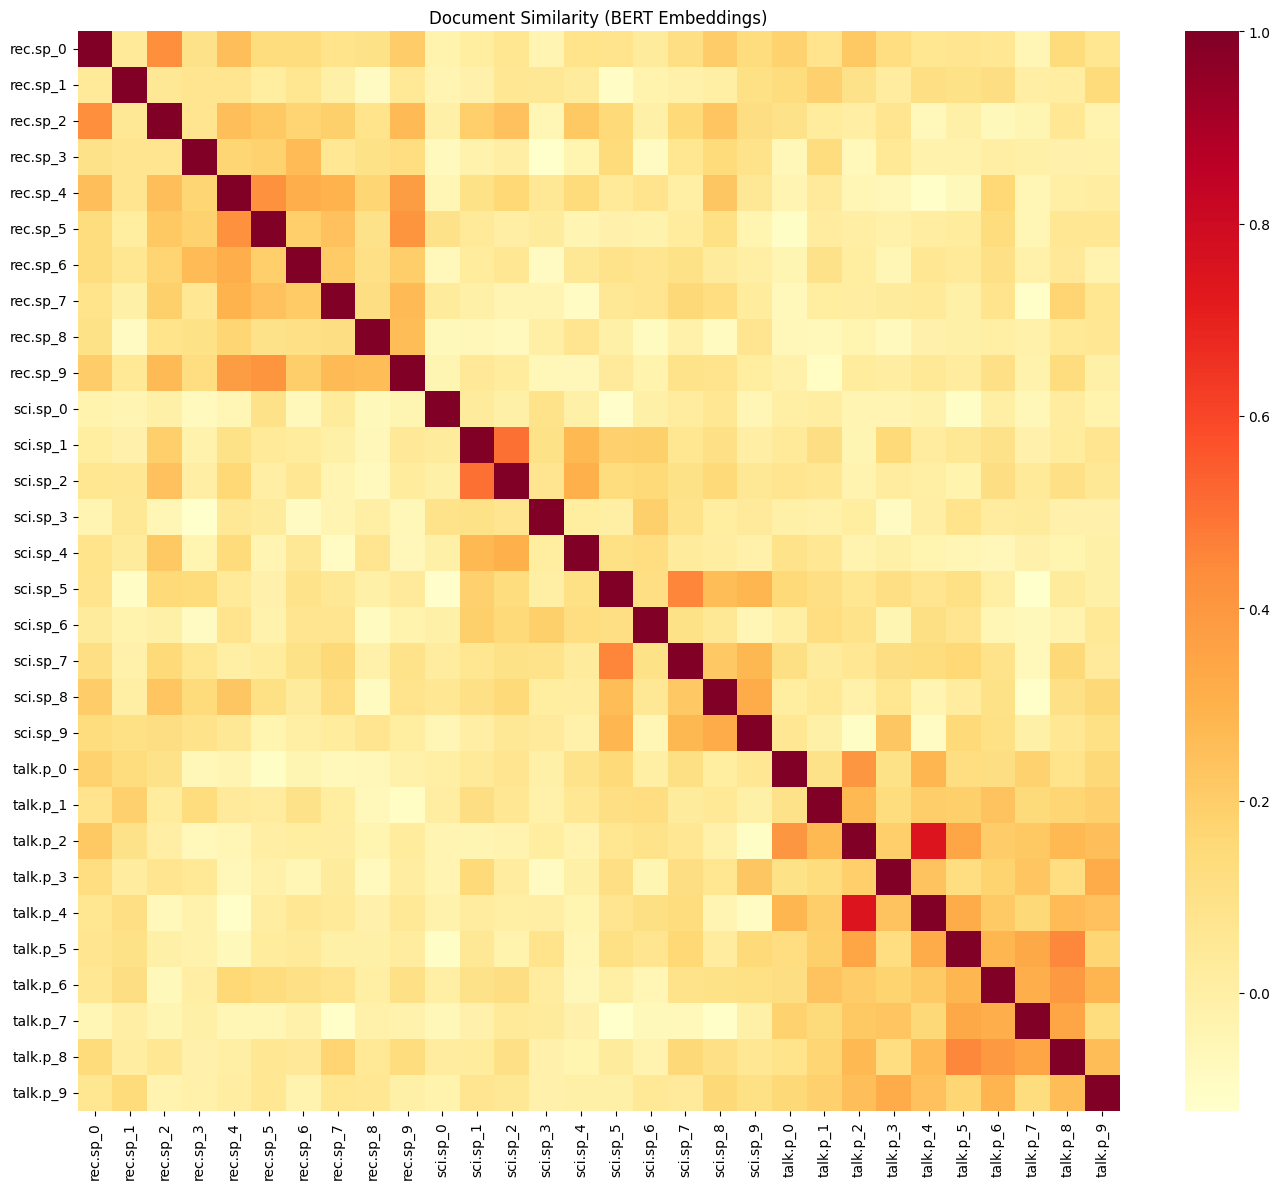

In [35]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. Better clustering with: BERT clusters better. 3 clear diagonal blocks, especially visible for talk.politics.

2. Differences between methods: Yes. BERT matches documents by meaning (paraphrases, synonyms), TF-IDF only by shared words. TF-IDF can also over-match on rare tokens like names or email signatures that BERT ignores.

3. Preferred method for classification: BERT for classification. Captures meaning, handles paraphrases, gives stronger features. TF-IDF stays a cheap baseline.

### Exercise C.2: Semantic Search with BERT

In [36]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    
    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return
        
    Returns:
        list: List of (index, similarity_score) tuples
    """
    # YOUR CODE HERE
    # 1. Encode the query
    # 2. Compute similarity with all documents
    # 3. Return top_k most similar
    query_emb = model.encode([query])
    doc_embs = model.encode(documents)
    sims = cosine_similarity(query_emb, doc_embs)[0]
    top_idx = sims.argsort()[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in top_idx]
    
# Test your search function
# TODO: Write a query related to ONE of your categories
my_query = "astronauts on a space shuttle mission"  # YOUR QUERY HERE

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'astronauts on a space shuttle mission'

Top 5 most similar documents:

  Score: 0.3096
  Category: sci.space
  Text: From another space forum
    When workers at the Kennedy Space Center disassembled the STS-56
 solid rocket boosters they were surprised to find a pai...

  Score: 0.2713
  Category: sci.space
  Text: 
Lets hear it for Dan Goldin...now if he can only convince the rest of
our federal government that the space program is a worth while
investment!

I h...

  Score: 0.2584
  Category: sci.space
  Text: I am doing a political science paper on the funding of NASA and pork-barrel 
politics.  I would be interested in information about funding practices a...

  Score: 0.2455
  Category: rec.sport.hockey
  Text: * The Keenan hiring is precipitated by the loss of an anticipated $5M
in playoff revenue and fears of losing season ticket-holders (!), plus
Paramount...

  Score: 0.1668
  Category: sci.space
  Text: 

He's also the one who dubbed it the SR-71 - it was the RS-71 u

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. Relevance: Yes, 4 out of 5 results are relevant (NASA, space program funding, shuttle boosters, SR-71). Scores are low (0.16–0.31) because the query is short compared to the documents.

2. Category accuracy: Yes, 4 out of 5 results are sci.space. The one mismatch is a hockey document about "Keenan hiring", probably picked up via the word "mission" or generic organizational vocabulary.

3. Ambiguous query test: Tried "funding and political decisions about national programs". Results mix sci.space (NASA funding) and talk.politics.mideast (government decisions), which is expected: the query is genuinely ambiguous, and BERT correctly retrieves both angles.

---

## Part D: Embedding Visualization with t-SNE

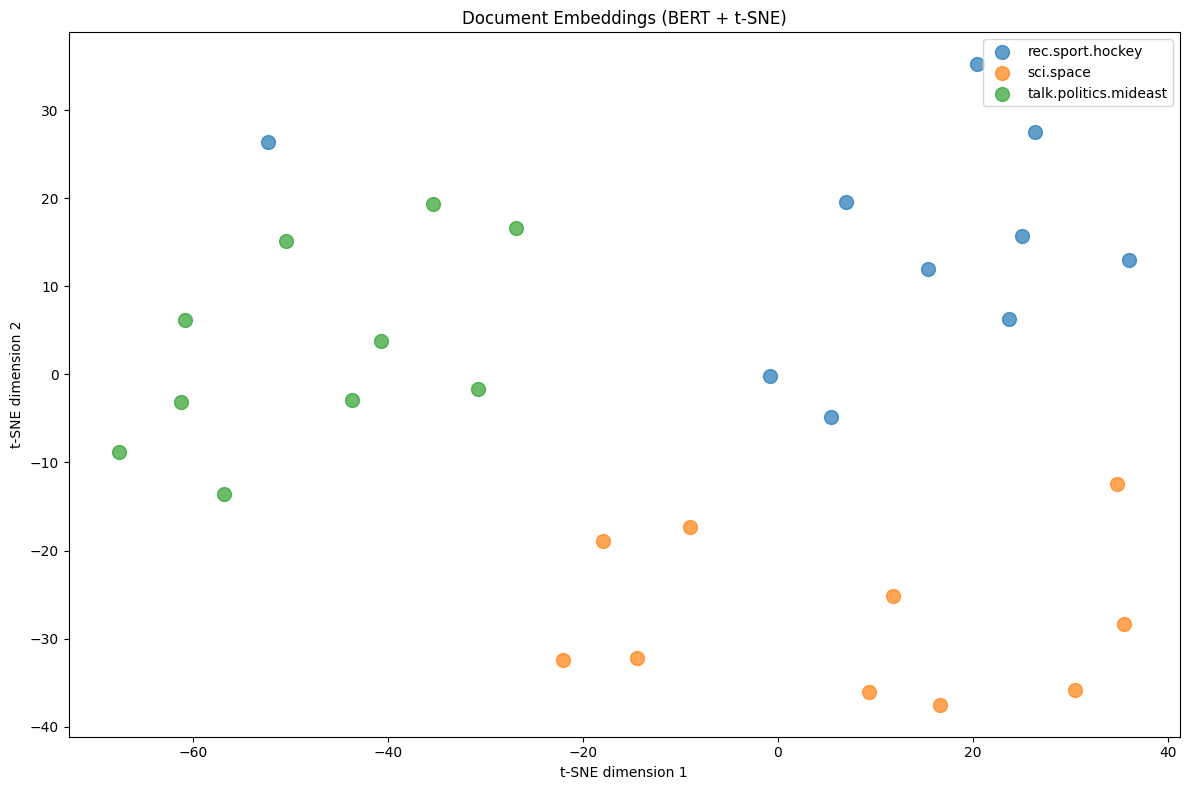

In [37]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. Cluster quality: Yes, fairly distinct. sci.space is clearly separated at the bottom, talk.politics.mideast on the left, rec.sport.hockey on the top-right. Not perfectly tight but clearly 3 zones.

2. Misplaced documents: Yes, a few. One hockey point sits at the far left among politics documents, and some hockey/politics points are mixed in the upper middle. Possible reason: documents with generic organizational vocabulary (teams, management, decisions) that overlap semantically across categories.

3. Most similar categories: rec.sport.hockey and talk.politics.mideast are the most similar (they overlap in the upper region). sci.space is the most separated. Makes sense: sport and politics both involve groups, conflict, and human organization, while space is more technical and distinct in vocabulary.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple, fast, interpretable | Ignores word order and meaning, huge sparse vectors | Quick baselines, small text classification |
| TF-IDF | Weights rare informative words, still simple | No semantics, no synonyms, sparse | Keyword search, baselines, topic filtering |
| Word2Vec | Learns semantic relations, dense vectors, trainable on own corpus | Needs enough data, one vector per word (no context) | Domain-specific tasks with a medium corpus |
| GloVe | Pre-trained on huge corpus, broad vocabulary, ready to use | Generic, weaker on specialized jargon, no context | Generic NLP tasks with small data |
| BERT | Contextual embeddings, captures meaning and paraphrases | Slow, heavy, less interpretable | Classification, semantic search, modern NLP |

### 2. Best Method for My Dataset

BERT worked best overall. The similarity heatmap showed 3 clear diagonal blocks, and t-SNE gave 3 visible clusters per category. Semantic search correctly returned 4 out of 5 sci.space documents for a space-related query, even when the exact words were not in the documents. TF-IDF would have missed these paraphrased matches. Word2Vec trained on my corpus was strong on domain terms (found real NASA centers like larc, ames, jsc), but only works at word level, not document level.

### 3. My Recommendation for a Real System

BERT embeddings + a simple classifier (logistic regression or a small MLP). It captures meaning, handles paraphrases, and generalizes well even with small training data. I would keep TF-IDF as a fast fallback baseline to compare against. Word2Vec/GloVe would only be useful if latency or cost made BERT unfeasible.


---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found